In [2]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [10]:
load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('INTELISTOCK_DB_USER')}:{os.getenv('INTELISTOCK_DB_PASSWORD')}@{os.getenv('INTELISTOCK_DB_HOST')}:{os.getenv('INTELISTOCK_DB_PORT')}/{os.getenv('INTELISTOCK_DB_NAME')}"
)

df = pd.read_sql(
    """
    SELECT v.fecha, p.nombre AS producto, vd.cantidad
    FROM ventas v
    JOIN venta_detalle vd ON vd.venta_id = v.id
    JOIN productos p ON p.id = vd.producto_id
    ORDER BY v.fecha
    """, engine
)

# Preparar  datos de Coca-Cola
coca = df[df['producto'] == 'Coca-Cola 600ml'].copy()
coca['fecha'] = pd.to_datetime(coca['fecha'])
coca = coca.sort_values('fecha').reset_index(drop=True)

coca['dia_numero'] = (coca['fecha'] - coca['fecha'].min()).dt.days
coca['dia_semana'] = coca['fecha'].dt.weekday
coca['es_fin_semana'] = (coca['dia_semana'] >= 5).astype(int)
coca['mes'] = coca['fecha'].dt.month

print(coca.shape)
coca.head()

(182, 7)


,fecha,producto,cantidad,dia_numero,dia_semana,es_fin_semana,mes
0,2024-01-01,Coca-Cola 600ml,17,0,0,0,1
1,2024-01-02,Coca-Cola 600ml,13,1,1,0,1
2,2024-01-03,Coca-Cola 600ml,12,2,2,0,1
3,2024-01-04,Coca-Cola 600ml,16,3,3,0,1
4,2024-01-05,Coca-Cola 600ml,10,4,4,0,1


In [15]:
# Features y target
X = coca[['dia_numero', 'dia_semana', 'es_fin_semana', 'mes']]
y = coca['cantidad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Regresión lineal
from sklearn.linear_model import LinearRegression
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
mae_lr = mean_absolute_error(y_test, modelo_lr.predict(X_test))

# Random Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
mae_rf = mean_absolute_error(y_test, modelo_rf.predict(X_test))

print(f"MAE Regresión Lineal: {mae_lr:.2f}")
print(f"MAE Random Forest:    {mae_rf:.2f}")

MAE Regresión Lineal: 3.80
MAE Random Forest:    4.15


         feature  importancia
0     dia_numero     0.605223
1     dia_semana     0.245451
2  es_fin_semana     0.080510
3            mes     0.068816


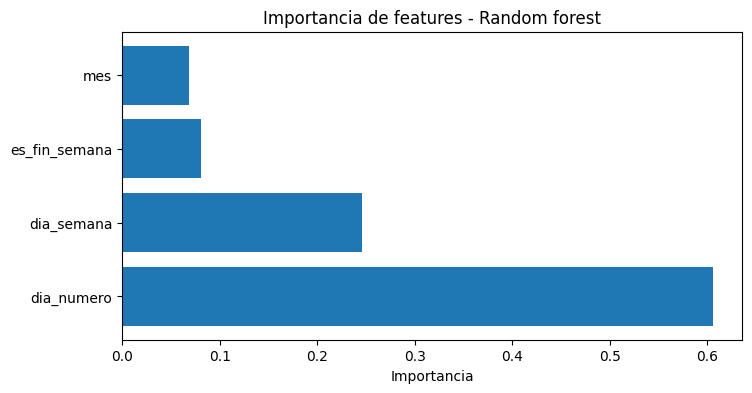

In [17]:
importancias = pd.DataFrame({
    'feature': X.columns,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=False)

print(importancias)

plt.figure(figsize=(8, 4))
plt.barh(importancias['feature'], importancias['importancia'])
plt.title("Importancia de features - Random forest")
plt.xlabel("Importancia")
plt.show()